In [26]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [34]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier

classifiers = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=22),
    "SVM": SVC(kernel='rbf', random_state=22),
    "Decision Tree": DecisionTreeClassifier(random_state=22),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Perceptron": Perceptron(max_iter=1000, random_state=22),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=22),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=22),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=22),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=22),
    "MLP Neural Net": MLPClassifier(max_iter=1000, random_state=22)
}

In [35]:
def prepare_data(dataset):
    X, y = dataset.data, dataset.target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

In [36]:
def evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    results = []

    avg_method = 'binary' if dataset_name == "Breast Cancer" else 'macro'

    for name, model in classifiers.items():
        start = time.time()
        model.fit(X_train, y_train)
        train_time = (time.time() - start) * 1000

        start = time.time()
        y_pred = model.predict(X_test)
        pred_time = (time.time() - start) * 1000

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average=avg_method),
            "Recall": recall_score(y_test, y_pred, average=avg_method),
            "F1 Score": f1_score(y_test, y_pred, average=avg_method),
            "Train Time (ms)": train_time,
            "Predict Time (ms)": pred_time
        })

    return pd.DataFrame(results)

In [37]:
iris = load_iris()
cancer = load_breast_cancer()

# Iris
X_train, X_test, y_train, y_test = prepare_data(iris)
iris_results = evaluate_models(X_train, X_test, y_train, y_test, "Iris")

# Cancer
X_train, X_test, y_train, y_test = prepare_data(cancer)
cancer_results = evaluate_models(X_train, X_test, y_train, y_test, "Breast Cancer")

iris_results

,Model,Accuracy,Precision,Recall,F1 Score,Train Time (ms),Predict Time (ms)
0,Naive Bayes,0.966667,0.969697,0.966667,0.966583,15.177488,1.235485
1,Logistic Regression,0.933333,0.933333,0.933333,0.933333,6.391287,0.000000
2,SVM,0.966667,0.969697,0.966667,0.966583,2.995014,1.003265
3,Decision Tree,0.966667,0.969697,0.966667,0.966583,2.998114,0.000000
4,KNN,0.933333,0.944444,0.933333,0.932660,0.000000,0.000000
5,Perceptron,0.800000,0.858586,0.800000,0.774603,5.999565,0.904083
6,Random Forest,0.933333,0.933333,0.933333,0.933333,312.305689,13.396978
7,Gradient Boosting,0.966667,0.969697,0.966667,0.966583,616.212368,0.000000
8,AdaBoost,0.933333,0.933333,0.933333,0.933333,332.176685,30.912638
9,Extra Trees,0.933333,0.933333,0.933333,0.933333,231.524706,20.336628


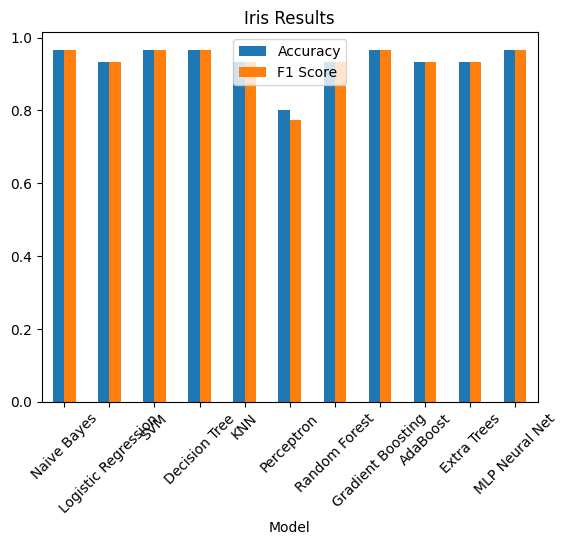

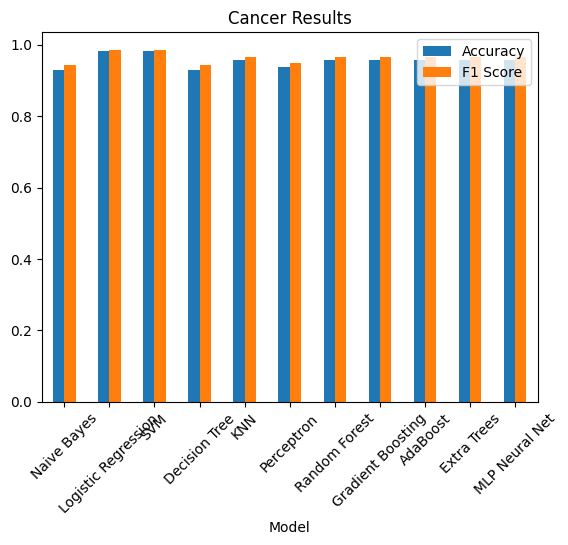

In [38]:
def plot_results(df, title):
    df.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_results(iris_results, "Iris Results")
plot_results(cancer_results, "Cancer Results")

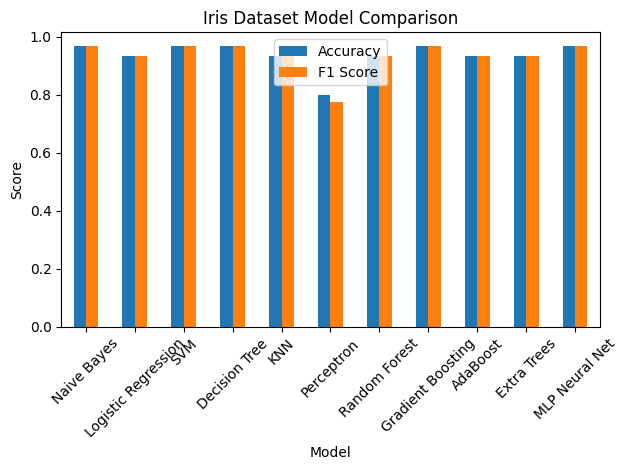

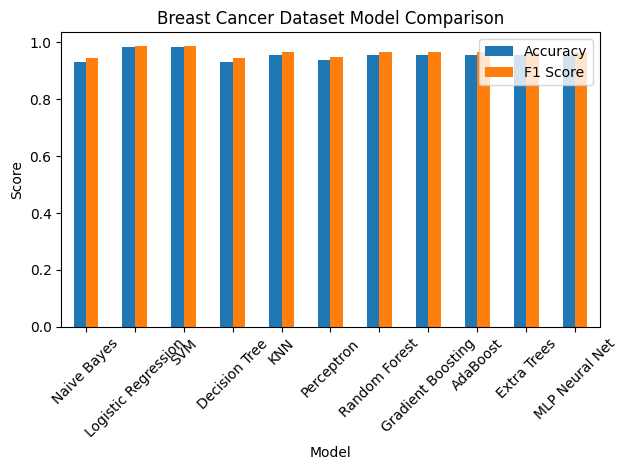

Step 6 Completed: Visualization generated successfully


In [39]:
import matplotlib.pyplot as plt

def plot_results(results, title):
    results = results.set_index("Model")
    
    results[["Accuracy", "F1 Score"]].plot(kind="bar")
    
    plt.title(title)
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot graphs
plot_results(iris_results, "Iris Dataset Model Comparison")
plot_results(cancer_results, "Breast Cancer Dataset Model Comparison")

print("Step 6 Completed: Visualization generated successfully")